# EXAMEN 1 - CORREGIDO

In [67]:
#Importe librerias esto creo que esta bien
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

In [68]:
#Cargue los dato
data=pd.read_csv('/Users/alevaldivia/Downloads/Lab_3/e01_datos.csv')

In [69]:
data.head()

,y,x1,x2,x3,grupo
0,13.643473,3.745401188473625,1.869147,6.363906,B
1,14.226813,9.50714306409916,6.743883,4.379466,A
2,15.312343,7.319939418114051,6.466175,5.648333,A
3,15.850062,5.986584841970366,3.012901,4.739714,A
4,15.477359,1.5601864044243652,1.443092,5.193992,B


In [70]:
data.dtypes

y        float64
x1           str
x2       float64
x3       float64
grupo        str
dtype: object

In [71]:
data.describe()

,y,x2,x3
count,183.000000,181.000000,182.000000
mean,14.053933,3.656675,5.054328
std,4.214684,2.596806,1.997665
min,4.000000,-2.194452,0.396158
25%,11.692237,1.603202,3.518048
50%,13.510425,3.463986,4.992027
75%,15.982460,5.689776,6.327197
max,42.000000,10.739239,11.157762


In [72]:
#Limpieza de datos
numerical_cols = ['x1','x2','x3'] #Olvide definir al inidio mis variables numericas y categoricas
categorical_cols = ['grupo'] 

data['x1'] = data['x1'].astype(str).str.replace(',', '.', regex=False) # x1 estaba como texto porque algunos datos tenian coma decimal
data['x1'] = pd.to_numeric(data['x1'], errors='coerce') #No habia guardado el cambio de tipo de dato en mi dataset 

In [73]:
# Reviso si tengo datos faltantes que olvide revisar antes de hacer la regresion lineal multiple
data.isna().sum()

y        0
x1       0
x2       2
x3       1
grupo    1
dtype: int64

Se encontraron valores faltantes en x2, x3 y grupo. No quiero eliminar automáticamente todas estas observaciones porque perdería información. Para las variables numéricas utilizaré la mediana dentro del Pipeline.

In [74]:
# Reviso las categorias de grupo
data['grupo'].value_counts(dropna=False)

grupo
A          73
B          60
C          42
a           1
 B          1
grupo_c     1
AA          1
c           1
NaN         1
b           1
D           1
Name: count, dtype: int64

Como se ve hay varios errores en la anotacion de los grupos por lo que es necesario limpiar los datos

In [75]:
# Quito espacios y convierto todas las categorias a mayusculas
data['grupo'] = data['grupo'].astype('string').str.strip().str.upper()
data['grupo'].value_counts(dropna=False)

grupo
A          74
B          62
C          43
GRUPO_C     1
AA          1
<NA>        1
D           1
Name: count, dtype: int64[pyarrow]

In [76]:
# Corrijo errores claros en los nombres de las categorias
data['grupo'] = data['grupo'].replace({
    'GRUPO_C':'C',
    'AA':'A'
})
data['grupo'].value_counts(dropna=False)

grupo
A       75
B       62
C       44
<NA>     1
D        1
Name: count, dtype: int64[pyarrow]

D no es un grupo definido por que no podemos tomar en cuenta esa categoria y hay que eliminarla 

In [77]:
# Elimino solo las observaciones donde no puedo conocer el grupo correcto
data = data[data['grupo'].isin(['A','B','C'])].copy()

Con esto eliminé dos observaciones de grupo: una tenía la categoría D y otra no tenía categoría. Debido a que el problema especifica que las únicas categorías posibles son A, B y C, no existe información suficiente para asignarlas correctamente sin inventar datos.

¿Cuál fue el error?
La variable grupo contenía categorías con diferencias de mayúsculas, espacios y nombres que no correspondían con A, B o C.

¿Cuál es la corrección?
Quité espacios, convertí los valores a mayúsculas y corregí errores evidentes como GRUPO_C y AA. Las observaciones con categoría D o sin categoría se eliminaron porque no era posible determinar su grupo real.

¿Por qué se cometió el error?
Los datos fueron capturados con formatos diferentes y algunas categorías fueron escritas incorrectamente.

¿Cómo evitarlo en el futuro?
Antes de usar una variable categórica revisar siempre que contienen los datos y limpiar todo a que se pueda usar

In [78]:
from sklearn.impute import SimpleImputer #tenia que agregar esta libreria para poder usar x2 y x3 ya que tenian datos faltantes
# Primero completo los datos faltantes con la mediana y despues estandarizo
numerical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
categorical_transformer = OneHotEncoder(
    drop='first',
    handle_unknown='ignore') #Por lo mismo de no definir mis variables no estab haciendo bien mi onenotencoder para convertir las categoricas

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]) #Olvide usar el colum trnsformer para estandarizar mis variables numericas y categoricas)

#X= ['x1','x2','x3'] tambien va grupo pero no recuerdo como hacerla numerica con onehot
X = data[['x1','x2','x3','grupo']] #con la transformacion correcta ya puedo usar todas mis variables en el modelo
y = data['y'] #Defini mi y comoo variable para poder usarla

¿Cuál fue el error?
No estabas transformando grupo, solo estabas creando el encoder. Ademas olvide la transformacion de columnas para estandarizar. 

¿Cuál es la corrección?
Meter grupo dentro de ColumnTransformer. Aplicar ColumTransformer.

¿Por qué se cometió el error?
Porque OneHotEncoder() por sí solo no sabe qué columna debe transformar. Y olvide el paso de estandarizacion. 

¿Cómo evitarlo en el futuro?
Cuando haya numéricas y categóricas, pensar siempre en limpiar los datos y guardarlos como corresponde asi como estandarizar para poder usar. 

In [79]:
#x_prom=X.mean()
#y_prom=y.mean()
#sum_x=np.sum((X - x_prom)**2)
#beta_1= (x_prom - sum_x)/y_prom
#beta_0= (x_prom - beta_1)/y_prom 

## esta parte esta mal por completo ya que yo estaba tratando de hacer una gresion lineal simple en lugar de multiple, ademas mi formula para betas era incorrecta
#los betas nos ayudan a sacar el modelo que estamos mejorando, esto es como se mueve y apartir de las variables x
#lr= LinearRegression() #Definimos que es un modelo de regresion lineal
#lr.fit(X,y) #aqui seharia la regresion lineal en nuestro modelo 
#lr.coef(X) #aqui seria el coeficiente
#lr.intercept() #este es nuestro intercepto
#lr.predict() #y este ya es nuestro R2 que nos dice como esta el modelo 

In [80]:
#Antes de hacer lo de fit y ver mi modelo tengo que entrenarlo y probarlo
# Separo mis datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=15
)


Qué significa:
- 80% se usa para entrenar
- 20% para probar
- random_state=15 hace que siempre tengas la misma división

Ya con esto podemos hacer pipeline y ver el modelo como quedo

In [81]:
lr = LinearRegression() #Definir mi modelo de regresion lineal

pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', lr)
    ]) #Se haace pipeline para unir el procesamiento de datos y el modelo de regresion

pipeline.fit(X_train, y_train) #Se entrena el modelo con los datos de entrenamiento que obtuvimos

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](4,)","['x1','x2','x3','grupo']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,4
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transforme

In [82]:
#Ahora si podemos ver que tan bien explica los datos el modelo
# Reviso que tan bien explica los datos de entrenamiento
r2_train = pipeline.score(X_train, y_train)

# Reviso que tan bien funciona con datos que no habia visto
r2_test = pipeline.score(X_test, y_test)

print('R2 train:', r2_train)
print('R2 test:', r2_test)

R2 train: 0.5481881842073923
R2 test: 0.7563413766290575


In [83]:
# Obtengo las predicciones del modelo (esto no es r2 como habia puesto en el examen)
y_pred = pipeline.predict(X_test)
print('Predicciones:', y_pred)

Predicciones: [10.33713999 14.71509268 11.60738545 15.15219817  9.02546306 11.02603769
 16.37293311 14.16588156 17.01489973 15.80623004 20.19749819  8.06009986
 15.81739803 14.50594866 13.31353894 11.88491701 15.0095968  14.98581125
  8.61923151 16.65066237 13.30972573 14.12047667  6.345616   10.02929671
 13.70304209 12.56547446 11.09943032 21.00176367 17.40913249  7.89784944
 14.96880418 14.23188412 14.57014203 13.52523669  8.74772874 15.34124103
 18.79489741]


In [84]:
#Este su es mi R2 que me dice que tan bien explica el modelo mis datos
pipeline.score(X_test, y_test)

0.7563413766290575

## Residuos

In [85]:
# Calculo los residuos (mi valor real menos mis predichos)
residuos = y_test - y_pred

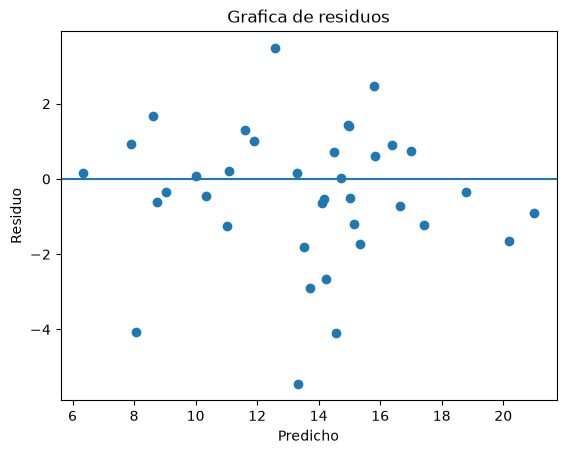

In [86]:
# Grafico los valores predichos contra los residuos 
plt.scatter(y_pred, residuos)
plt.axhline(0)

plt.xlabel('Predicho')
plt.ylabel('Residuo')
plt.title('Grafica de residuos')

plt.show()

Los residuos están alrededor de cero y no se observa un patron de curva muy claro, por lo que inicialmente no parece haber una fuerte no linealidad. Sin embargo, hay algunos residuos muy alejados de cero y una mayor dispersión en algunas zonas, así que después se deben revisar outliers y heterocedasticidad.

## Validacion cruzada

In [87]:
# Creo validacion cruzada de 5 partes con KFold
kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=15
)

In [88]:
# Calculo el R2 en cada division
scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=kfold,
    scoring='r2'
)

print(scores)
print('R2 promedio:', scores.mean())

[0.75634138 0.55136267 0.71379168 0.3998894  0.58855259]
R2 promedio: 0.6019875428352501


El modelo lineal múltiple obtiene un R2 promedio de validación cruzada cercano a 0.60. Esto significa que el modelo explica aproximadamente 60% de la variación de y en las diferentes particiones. El resultado muestra que existe capacidad explicativa, pero todavía hay variación sin explicar y es necesario revisar los residuos y los seis problemas comunes antes de decidir si el modelo es suficiente.

## 6 errores comunes

In [89]:
# No linealidad

from sklearn.preprocessing import PolynomialFeatures

# Creo una transformacion polinomial grado 2 para revisar si mejora la relacion
numerical_poly = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('poly', PolynomialFeatures(degree=2, include_bias=False))
    ]
)

# Preprocesamiento para el modelo polinomial
preprocessor_poly = ColumnTransformer(
    transformers=[
        ('num', numerical_poly, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

# Creo el modelo polinomial
pipeline_poly = Pipeline(
    steps=[
        ('preprocessor', preprocessor_poly),
        ('model', LinearRegression())
    ]
)

# Comparo el modelo polinomial con validacion cruzada
scores_poly = cross_val_score(
    pipeline_poly,
    X,
    y,
    cv=kfold,
    scoring='r2'
)

print(scores_poly)
print('R2 promedio polinomial:', scores_poly.mean())

[0.73101099 0.53217279 0.71555888 0.36209897 0.49726403]
R2 promedio polinomial: 0.5676211344702533


Para revisar si existía una relacion no lineal, comparé el modelo lineal con una regresión polinomial de grado 2 usando la misma validación cruzada. El modelo polinomial obtuvo un R² promedio menor que el modelo lineal. Por lo tanto, agregar términos cuadráticos no mejoro la capacidad de generalización del modelo. Esto coincide con la gráfica de residuos, donde no se observaba una curvatura clara.

In [90]:
# Correlacion

from sklearn.model_selection import cross_val_predict

# Obtengo predicciones de validacion cruzada para todos los datos
pred_cv = cross_val_predict(
    pipeline,
    X,
    y,
    cv=kfold
)

# Calculo los residuos de validacion cruzada
residuos_cv = y - pred_cv

# Calculo Durbin Watson para revisar correlacion de errores
DW = np.sum(np.diff(residuos_cv)**2) / np.sum(residuos_cv**2)

print('Durbin Watson:', DW)

Durbin Watson: 2.059794650511724


El estadístico Durbin-Watson fue cercano a 2, con un valor aproximado de 2.06. Esto indica que no se observa una correlacion importante entre los residuos.

In [91]:
# Colinealidad

# Creo una copia de mis variables para revisar colinealidad
X_vif = data[['x1','x2','x3']].copy()

# Completo los datos faltantes para poder calcular VIF
X_vif['x1'] = X_vif['x1'].fillna(X_vif['x1'].median())
X_vif['x2'] = X_vif['x2'].fillna(X_vif['x2'].median())
X_vif['x3'] = X_vif['x3'].fillna(X_vif['x3'].median())

# Convierto grupo a variables dummy para poder incluirla
grupo_dummy = pd.get_dummies(
    data['grupo'],
    drop_first=True,
    dtype=int
)

X_vif = pd.concat(
    [X_vif, grupo_dummy],
    axis=1
)

# Calculo VIF de cada variable
vif_resultados = []

for columna in X_vif.columns:

    X_aux = X_vif.drop(columns=[columna])
    y_aux = X_vif[columna]

    modelo_aux = LinearRegression()
    modelo_aux.fit(X_aux, y_aux)

    r2_aux = modelo_aux.score(X_aux, y_aux)

    vif = 1 / (1 - r2_aux)

    vif_resultados.append([columna, vif])

# Creo un DataFrame con los resultados de VIF
vif_tabla = pd.DataFrame(
    vif_resultados,
    columns=['Variable','VIF']
)

vif_tabla

,Variable,VIF
0,x1,4.502626
1,x2,4.500001
2,x3,1.004717
3,B,1.230770
4,C,1.208319


Los valores más altos de VIF corresponden a x1 y x2, con valores cercanos a 4.5. Existe cierta relacion entre estas dos variables, pero ninguna supera el criterio de 10 utilizado para identificar colinealidad fuerte. Por lo tanto, no considero que exista un problema grave de colinealidad.

In [92]:
# Outliers

# Estandarizo los residuos de validacion cruzada para poderbuscar residuis
residuos_est = (
    residuos_cv - residuos_cv.mean()
) / residuos_cv.std()

# Busco residuos mayores a 3 o menores a -3
outliers = data[
    np.abs(residuos_est) > 3
].copy()

outliers

,y,x1,x2,x3,grupo
180,42.0,9.8,8.0,5.0,A
182,38.0,9.5,9.2,8.0,B


In [93]:
# Agrego el residuo estandarizado
outliers['residuo_estandarizado'] = residuos_est[
    np.abs(residuos_est) > 3
]

outliers

,y,x1,x2,x3,grupo,residuo_estandarizado
180,42.0,9.8,8.0,5.0,A,8.827355
182,38.0,9.5,9.2,8.0,B,5.709277


Se identificaron dos observaciones con residuos estandarizados mayores a 3 en valor absoluto. Sus valores de y son 42 y 38 y presentan residuos estandarizados muy superiores al resto de los datos. Por esta razón se consideran posibles outliers. MAs adelante los eliminare

In [94]:
#HL

# Transformo X de la misma manera que en el modelo
X_transformado = preprocessor.fit_transform(X)

# Agrego la columna del intercepto
X_diseno = np.column_stack(
    [
        np.ones(len(X_transformado)),
        X_transformado
    ]
)

# Calculo la matriz H para obtener leverage
H = (
    X_diseno
    @ np.linalg.pinv(X_diseno.T @ X_diseno)
    @ X_diseno.T
)

# El leverage esta en la diagonal de H
leverage = np.diag(H)

# Calculo el limite para considerar high leverage
p = X_diseno.shape[1] #obtiene el número de columnas que tiene tu modelo despues de las transformaciones.
n = X_diseno.shape[0] #obtiene el número de observaciones

limite_leverage = 2*p/n

print('Limite:', limite_leverage)

# Agrego el leverage a mis datos
data_leverage = data.copy()

data_leverage['leverage'] = leverage

# Identifico las observaciones high leverage
high_leverage = data_leverage[
    data_leverage['leverage'] > limite_leverage
]

high_leverage

Limite: 0.06629834254143646


,y,x1,x2,x3,grupo,leverage
12,16.398547,4.271000,6.869650,6.248240,A,0.068785
73,12.789632,8.154614,10.739239,3.846193,C,0.107151
126,15.926778,8.180148,2.245590,0.865116,B,0.120470
162,23.856925,6.335297,5.726907,11.157762,B,0.071952


Se encontraron algunas observaciones con leverage mayor al criterio 2. Esto significa que tienen combinaciones de variables X diferentes al resto. Sin embargo, una observación high leverage no necesariamente es incorrecta, por lo que no se eliminan únicamente por esta razón.

In [95]:
# Heterocedasticidad

# Creo una tabla con predicciones y residuos
residuos_tabla = pd.DataFrame({
    'predicho': pred_cv,
    'residuo': residuos_cv
})

# Divido las predicciones en cuatro grupos
residuos_tabla['grupo_predicho'] = pd.qcut(
    residuos_tabla['predicho'],
    q=4
)

# Comparo la dispersion de residuos por grupo
residuos_tabla.groupby(
    'grupo_predicho',
    observed=True
)['residuo'].std()

grupo_predicho
(6.345, 11.905]     1.431525
(11.905, 14.166]    1.741452
(14.166, 16.373]    1.729766
(16.373, 22.62]     4.893312
Name: residuo, dtype: float64

La desviación de los residuos es parecida en los primeros tres grupos de predicción, pero aumenta bastante en el grupo de predicciones más altas. Esto sugiere heterocedasticidad, ya que la variabilidad de los errores no parece ser constante. Sin embargo, esta diferencia puede estar influida por los dos outliers identificados anteriormente.

In [96]:
# Elimino los outliers y vuelvo a entrenar el modelo

# Elimino únicamente los outliers detectados con el criterio de residuo estandarizado
data_sin_outliers = data[
    np.abs(residuos_est) <= 3
].copy()

Después de revisar los seis problemas, los dos puntos con valores de y de 42 y 38 fueron los casos más claros de comportamiento atípico. No los elimino solamente porque sus valores sean grandes, sino porque sus residuos estandarizados superan ampliamente el criterio de 3 y además aumentan la dispersión de los errores.

In [97]:
#Mejorar el modelo
# Defino nuevamente X y y sin los dos outliers
X_mejorado = data_sin_outliers[
    ['x1','x2','x3','grupo']
]

y_mejorado = data_sin_outliers['y']

In [98]:
# Evaluo nuevamente el modelo lineal con validacion cruzada
scores_mejorado = cross_val_score(
    pipeline,
    X_mejorado,
    y_mejorado,
    cv=kfold,
    scoring='r2'
)

print(scores_mejorado)
print(
    'R2 promedio modelo mejorado:',
    scores_mejorado.mean()
)

[0.71510181 0.66494086 0.71679952 0.72936497 0.78529266]
R2 promedio modelo mejorado: 0.7222999627427364


Después de eliminar únicamente los dos outliers identificados, el R² promedio de validación cruzada aumento aproximadamente de 0.60 a 0.72. Esto indica que las dos observaciones estaban afectando de forma importante el ajuste y la capacidad de generalización del modelo.

In [99]:
# Comparo el modelo original contra el modelo corregido
comparacion = pd.DataFrame({
    'Modelo': [
        'Lineal original',
        'Lineal sin outliers',
        'Polinomial grado 2'
    ],
    'R2 CV': [
        scores.mean(),
        scores_mejorado.mean(),
        scores_poly.mean()
    ]
})

comparacion

,Modelo,R2 CV
0,Lineal original,0.601988
1,Lineal sin outliers,0.722300
2,Polinomial grado 2,0.567621


El modelo inicial de regresión lineal múltiple obtuvo un R2 promedio de validación cruzada cercano a 0.60. Al revisar los seis problemas comunes no se encontró evidencia importante de no linealidad ni de correlación de errores. Se encontró cierta relación entre x1 y x2, pero los valores de VIF no fueron mayores a 10, por lo que no se consideró colinealidad grave.  

El principal problema fueron dos observaciones con residuos estandarizados mayores a 3, correspondientes a valores de y de 42 y 38. Estas observaciones también aumentaban considerablemente la dispersión de los residuos en las predicciones altas. Después de eliminarlas con una justificación basada en los residuos, el R2 promedio de validación cruzada aumentó aproximadamente de 0.60 a 0.72.
También se probó un modelo polinomial de grado 2, pero su desempeño fue menor al del modelo lineal. Por esta razón, el modelo lineal múltiple sin los dos outliers es una mejor alternativa para estos datos, ya que logra un mejor resultado de validacion cruzada sin agregar complejidad innecesaria.